In [1]:
!pip install datasets pandas matplotlib seaborn scikit-learn nltk

In [2]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("surrey-nlp/BESSTIE-CW-26")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})


In [3]:
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

df = pd.concat([train_df, val_df, test_df])

df.head()

,text,variety,source,Sentiment,Sarcasm
0,I'm a member of the Green Party but I'll be vo...,en-UK,Reddit,0.0,0.0
1,Yeah it blew out to 3x what it was budgeted fo...,en-AU,Reddit,0.0,1.0
2,"Food was pretty great. A little dry, but I am ...",en-AU,Google,1.0,0.0
3,Firstly the staff seemed as if they did n't wa...,en-UK,Google,0.0,0.0
4,We came for lunch and enjoyed the food we orde...,en-UK,Google,1.0,0.0


In [4]:
print("Dataset shape:", df.shape)
print(df.columns)

df['variety'].value_counts()

Dataset shape: (6243, 5)
Index(['text', 'variety', 'source', 'Sentiment', 'Sarcasm'], dtype='object')


,count
variety,
en-IN,2332
en-UK,2004
en-AU,1907


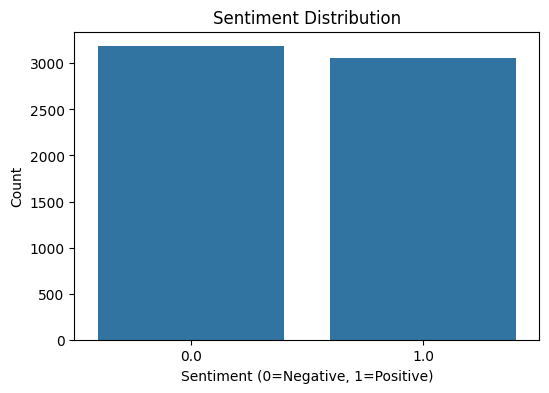

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sentiment')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0=Negative, 1=Positive)")
plt.ylabel("Count")
plt.show()

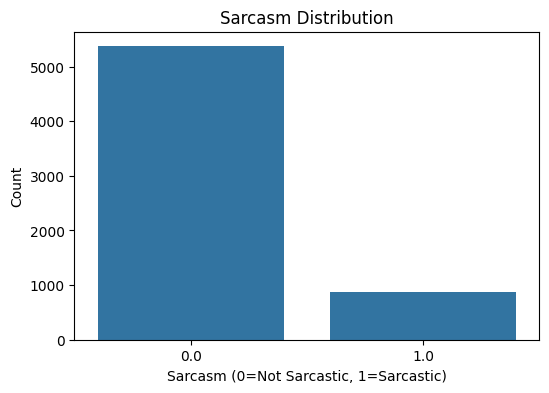

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sarcasm')
plt.title("Sarcasm Distribution")
plt.xlabel("Sarcasm (0=Not Sarcastic, 1=Sarcastic)")
plt.ylabel("Count")
plt.show()

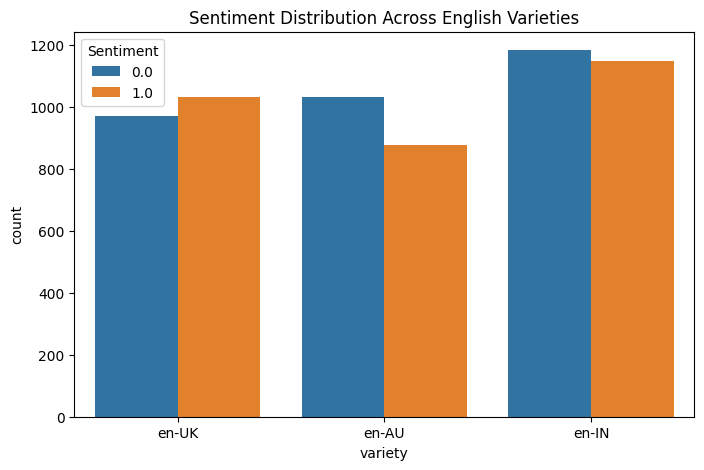

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='variety', hue='Sentiment')
plt.title("Sentiment Distribution Across English Varieties")
plt.show()

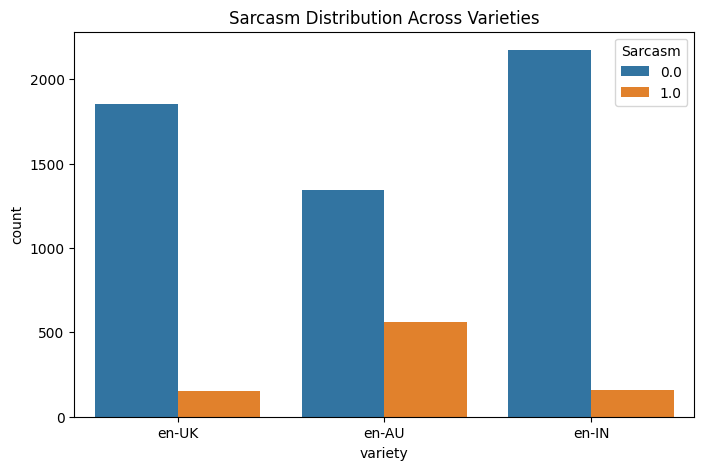

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='variety', hue='Sarcasm')
plt.title("Sarcasm Distribution Across Varieties")
plt.show()

In [14]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

sample_text = df['text'].iloc[0]

tokens = word_tokenize(sample_text)

print("Sample text:", sample_text)
print("Tokens:", tokens)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Sample text: I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.
Tokens: ['I', "'m", 'a', 'member', 'of', 'the', 'Green', 'Party', 'but', 'I', "'ll", 'be', 'voting', 'Lib', 'Dem', 'as', 'it', "'s", 'so', 'tight', 'here', 'between', 'Lib', 'Dem', 'and', 'Tory', '.', 'I', 'can', 'not', 'contemplate', 'our', 'useless', 'tit', 'of', 'a', 'Tory', 'MP', 'being', 'reelected', '.', 'I', "'ll", 'use', 'the', 'Swap', 'My', 'Vote', 'website', 'so', 'someone', 'somewhere', 'can', 'vote', 'Green', 'for', 'me', '.']


In [15]:
from collections import Counter
import re

def get_vocab(text_series):

    words = []

    for text in text_series:
        tokens = re.findall(r'\b\w+\b', text.lower())
        words.extend(tokens)

    return set(words)

uk_vocab = get_vocab(df[df['variety']=='en-UK']['text'])
in_vocab = get_vocab(df[df['variety']=='en-IN']['text'])

print("UK vocab size:", len(uk_vocab))
print("IN vocab size:", len(in_vocab))

UK vocab size: 9777
IN vocab size: 9603


In [16]:
intersection = uk_vocab.intersection(in_vocab)
union = uk_vocab.union(in_vocab)

jaccard_similarity = len(intersection) / len(union)

print("Jaccard Similarity:", jaccard_similarity)

Jaccard Similarity: 0.3056659704911406


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

uk_text = " ".join(df[df['variety']=='en-UK']['text'])
in_text = " ".join(df[df['variety']=='en-IN']['text'])

vectorizer = TfidfVectorizer(max_features=5000)

tfidf = vectorizer.fit_transform([uk_text, in_text])

similarity = cosine_similarity(tfidf[0], tfidf[1])

print("Cosine Similarity:", similarity[0][0])

Cosine Similarity: 0.9522511952689596
